# Aplicação Knn + SMOTE

Import de bibliotecas

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import shap

e:\Faculdade\PISI3\projetodb\PISI3\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load do DF

In [2]:
df = pd.read_csv("..\\datasets_paralelos\\kmeans_7clusters.csv")

In [3]:
# Carregar os dados
new_df = df.copy()

# Separar features (X) e target (y)
X = new_df.drop(columns=['cluster'])  # Features
y = new_df['cluster']                # Target

In [4]:
# Dividir dados em treino e teste (30% para teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Definir o modelo com hyperparâmetros de regularização
model = KNeighborsClassifier(
    n_neighbors=5,       # número de vizinhos (padrão: 5)
    weights='distance',   # ou 'distance' para ponderar pela distância
    metric='minkowski',  # distância padrão (p=2 → Euclidiana)
    n_jobs=-1            # usa todos os núcleos do processador
)

pipeline = Pipeline([    # muito importante para KNN
    ('smote', SMOTE(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])



# Treinar o modelo
pipeline.fit(X_train, y_train)



Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('knn', KNeighborsClassifier())])

# Avaliação teste

In [5]:
# Previsões no conjunto de treino
y_teste_pred = pipeline.predict(X_test)

Matriz de Confusão para o conjunto de teste:
[[5134   72   50    0   77    2  131]
 [  50 4565   39   63   32    6   91]
 [  22    9 1684    6   13    6   10]
 [   0   21    4 1895   19    1    0]
 [  19   17   19   36 2805    0    6]
 [   0    1    5    0    0  331    1]
 [ 187  158   52    0   61   15 6688]]


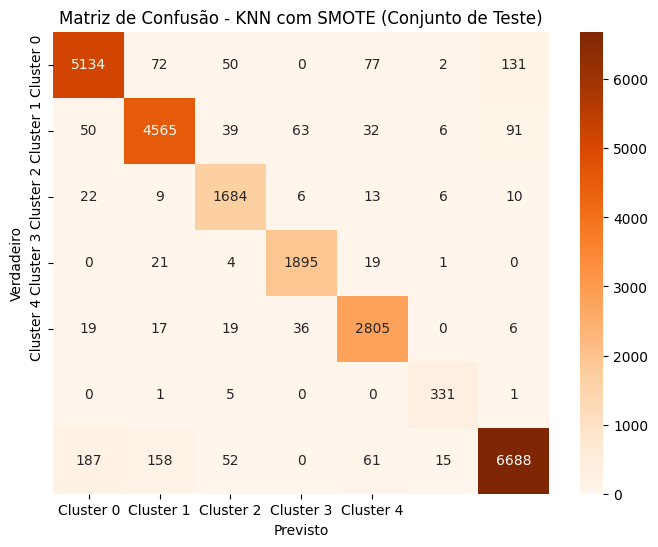

In [6]:
conf_matrix_teste= confusion_matrix(y_test, y_teste_pred)
print("Matriz de Confusão para o conjunto de teste:")
print(conf_matrix_teste)

# Criar os rótulos para os clusters
cluster_labels = [f'Cluster {i}' for i in range(5)]  # Se os clusters forem 0 a 4

# Plotar a matriz de confusão para o conjunto de treino
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_teste, annot=True, fmt='d', cmap='Oranges',
            xticklabels=cluster_labels, yticklabels=cluster_labels)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - KNN com SMOTE (Conjunto de Teste)')
plt.show()



In [7]:
# Relatório de classificação para o conjunto de teste
print("\nMétricas de Classificação para o conjunto de teste:")
print(classification_report(y_test, y_teste_pred, target_names=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5', 'Cluster 6']))


Métricas de Classificação para o conjunto de teste:
              precision    recall  f1-score   support

   Cluster 0       0.95      0.94      0.94      5466
   Cluster 1       0.94      0.94      0.94      4846
   Cluster 2       0.91      0.96      0.93      1750
   Cluster 3       0.95      0.98      0.96      1940
   Cluster 4       0.93      0.97      0.95      2902
   Cluster 5       0.92      0.98      0.95       338
   Cluster 6       0.97      0.93      0.95      7161

    accuracy                           0.95     24403
   macro avg       0.94      0.96      0.95     24403
weighted avg       0.95      0.95      0.95     24403



# Avaliação do conjunto de treino

In [8]:
# Previsões no conjunto de treino
y_train_pred = pipeline.predict(X_train)


Matriz de Confusão para o conjunto de treino:
[[12376    87    76     0    93     6   128]
 [   57 10866    52    88    30    10    71]
 [    6     1  4014     1     5     1     0]
 [    0     9     0  4597     6     0     0]
 [   10     9    25    16  6659     0     2]
 [    0     0     0     0     0   690     0]
 [  253   232   115     0   120    21 16208]]


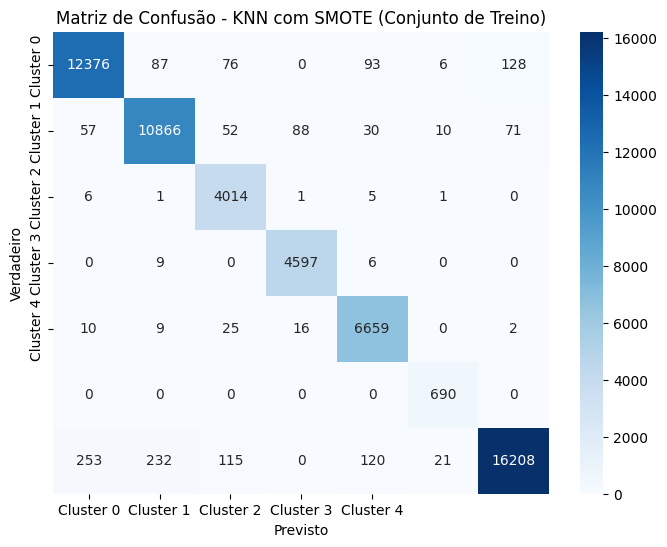

In [9]:

# Matriz de Confusão para o conjunto de treino
conf_matrix_train = confusion_matrix(y_train, y_train_pred)
print("Matriz de Confusão para o conjunto de treino:")
print(conf_matrix_train)

# Criar os rótulos para os clusters
cluster_labels = [f'Cluster {i}' for i in range(5)]  # Se os clusters forem 0 a 4

# Plotar a matriz de confusão para o conjunto de treino
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=cluster_labels, yticklabels=cluster_labels)
plt.xlabel('Previsto')
plt.ylabel('Verdadeiro')
plt.title('Matriz de Confusão - KNN com SMOTE (Conjunto de Treino)')
plt.show()



In [10]:
# Relatório de classificação para o conjunto de treino
print("\nMétricas de Classificação para o conjunto de treino:")
print(classification_report(y_train, y_train_pred, target_names=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5', 'Cluster 6']))


Métricas de Classificação para o conjunto de treino:
              precision    recall  f1-score   support

   Cluster 0       0.97      0.97      0.97     12766
   Cluster 1       0.97      0.97      0.97     11174
   Cluster 2       0.94      1.00      0.97      4028
   Cluster 3       0.98      1.00      0.99      4612
   Cluster 4       0.96      0.99      0.98      6721
   Cluster 5       0.95      1.00      0.97       690
   Cluster 6       0.99      0.96      0.97     16949

    accuracy                           0.97     56940
   macro avg       0.97      0.98      0.97     56940
weighted avg       0.97      0.97      0.97     56940



In [ ]:
# Gerar valores SHAP para o modelo KNN
X_test_summary = shap.sample(X_test, 100)
explainer = shap.KernelExplainer(model.predict_proba, X_test_summary)
shap_values = explainer.shap_values(X_test)

# Gráfico summary plot para a classe 1 (Popular)
shap.summary_plot(shap_values[:, :, 1], X_test, feature_names=X_test.columns)

# Cross Validation

In [11]:
# Cross-validation para avaliar overfitting no modelo KNN com SMOTE
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)
print("Acurácias de cross-validation:", cv_scores)
print("Média da acurácia de cross-validation:", np.mean(cv_scores))

# Calcular acurácia no treino e teste
train_acc = pipeline.score(X_train, y_train)
test_acc = pipeline.score(X_test, y_test)
print("Acurácia no treino:", train_acc)
print("Acurácia no teste:", test_acc)

Acurácias de cross-validation: [0.93853179 0.94046365 0.94520548 0.94546891 0.94441517]
Média da acurácia de cross-validation: 0.942817000351247
Acurácia no treino: 0.9731296101159115
Acurácia no teste: 0.9466868827603163
